<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:28: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:28: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_343466/3790831251.py:10: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(timinglog, sep='\s+', header=4)
/tmp/ipykernel_343466/3790831251.py:28: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(timinglog, sep='\s+', header=4)


Text(0.5, 1.0, 'Compy NE30pg2 10-d Run Performance (mamf90 vs mamxx)')

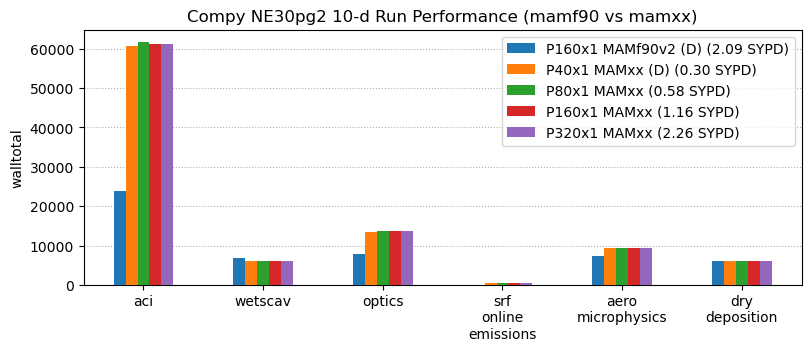

In [2]:
from glob import glob 
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np 

def grab_timing_mamf90(case):

    timinglog = glob(f'{case}/e3sm_timing_stats.*')[-1]   
    sypdlog = glob(f'{case}/e3sm_timing.*')[-1]   
    df = pd.read_csv(timinglog, sep='\s+', header=4) 
    s1 = df['name'].str.startswith('a:MAM') 
    df1 = df[s1][['name', 'count', 'walltotal']] 
    processes = [p for p in df1['name'].str.split(':').str[2]]  
    df1['name'] = processes 
    
    # SYPD
    lines_to_read = range(33, 39)  # 1-based
    with open(sypdlog) as f:
        all_lines = f.readlines()
    result = [all_lines[i-1].rstrip() for i in lines_to_read]
    return df1, processes, result


def grab_timing_mamxx(case):
    
    timinglog = glob(f'{case}/e3sm_timing_stats.*')[-1]   
    sypdlog = glob(f'{case}/e3sm_timing.*')[-1]   
    df = pd.read_csv(timinglog, sep='\s+', header=4) 
    s1 = df['name'].str.startswith('a:EAMxx::mam') 
    s2 = df['name'].str.endswith('::run')
    df3 = df[s1 & s2][1:][['name', 'count', 'walltotal']] 
    processes = [p for p in df3['name'].str.split('::').str[1]]  
    df3['name'] = processes 

    # SYPD
    lines_to_read = range(34, 40)  # 1-based
    with open(sypdlog) as f:
        all_lines = f.readlines()
    result = [all_lines[i-1].rstrip() for i in lines_to_read]
    return df3, processes, result


def convert_mamf90_to_mamxx(df1):
    df1_time_new = [
        df1[df1['name'] == 'microp_aero_run_aci']['walltotal'].values,
        df1[df1['name'] == ' Wetdep']['walltotal'].values,
        df1[df1['name'] == 'aer_rad_props_sw']['walltotal'].values + df1[df1['name'] == 'aer_rad_props_lw']['walltotal'].values, 
        df1[df1['name'] == 'chem_emissions']['walltotal'].values,
        df1[df1['name'] == 'chem_timestep_tend']['walltotal'].values,
        df1[df1['name'] == 'aero_drydep']['walltotal'].values,
    ]
    df1_time_new = np.array(df1_time_new).flatten()
    return df1_time_new 


indir = '/pscratch/sd/m/meng/tmp/compy'
cases = {
    'P160x1 MAMf90v2 (D)': f'{indir}/SMS_Ld10.ne30pg2_oECv3.F2010.compy_intel.mamf90-v2/timing',
    'P40x1 MAMxx (D)': f'{indir}/SMS_Ld10.ne30pg2_oECv3.F2010-EAMxx-MAM4xx.compy_intel.mamxx/timing',
    'P80x1 MAMxx': f'{indir}/SMS_P80x1_Ld10.ne30pg2_oECv3.F2010-EAMxx-MAM4xx.compy_intel.mamxx/timing',
    'P160x1 MAMxx': f'{indir}/SMS_P160x1_Ld10.ne30pg2_oECv3.F2010-EAMxx-MAM4xx.compy_intel.mamxx/timing',
    'P320x1 MAMxx': f'{indir}/SMS_P320x1_Ld10.ne30pg2_oECv3.F2010-EAMxx-MAM4xx.compy_intel.mamxx/timing', 
}

df_combined = {}
for cn, c in cases.items():
    if 'MAMf90' in cn:
        df, processes, result = grab_timing_mamf90(c)
        out = convert_mamf90_to_mamxx(df) 
    else:
        df, processes, result = grab_timing_mamxx(c)
        out = df['walltotal'].values 
        pdp = processes 
    
    casename = cn + f" ({result[1].split()[2]} SYPD)"
    df_combined[casename] = out 

df_combined = pd.DataFrame(df_combined)
df_combined['name'] = pdp

fig, ax = plt.subplots(figsize=(8, 3.4), constrained_layout=True)
df_combined.set_index('name').plot.bar(ax=ax, zorder=99)
ax.set_xticklabels([f'{("\n").join(p.split("_")[1:])}' for p in pdp], rotation=0)
ax.set_ylabel('walltotal')
ax.set_xlabel('')
ax.grid(axis='y', ls=':')
ax.set_title('Compy NE30pg2 10-d Run Performance (mamf90 vs mamxx)')